In [4]:
import torch
import sys
from pathlib import Path

this_path = Path(__file__) if '__file__' in globals() else Path("<unknown>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

from run_manager import RunViewer


In [5]:
rv = RunViewer(exp_path=this_path.parent)

sd = torch.load(rv[3] / "state_dict.pt")


In [7]:
for name, param in sd.items():
    if 'weight' in name and param.dtype in (torch.float32, torch.float64, torch.float16):
        print(f"{name} - Mean: {param.mean().item():.4f}, Std: {param.std().item():.4f}")

base_model.conv1.1.weight - Mean: -0.0008, Std: 0.2289
base_model.bn1.weight - Mean: 0.9648, Std: 0.0053
base_model.layer1.0.conv1.weight - Mean: 0.0020, Std: 0.2299
base_model.layer1.0.bn1.weight - Mean: 0.9646, Std: 0.0036
base_model.layer1.0.conv2.weight - Mean: 0.0011, Std: 0.2252
base_model.layer1.0.bn2.weight - Mean: 0.9644, Std: 0.0037
base_model.layer1.1.conv1.weight - Mean: 0.0005, Std: 0.2275
base_model.layer1.1.bn1.weight - Mean: 0.9646, Std: 0.0026
base_model.layer1.1.conv2.weight - Mean: 0.0025, Std: 0.2242
base_model.layer1.1.bn2.weight - Mean: 0.9645, Std: 0.0026
base_model.layer2.0.conv1.weight - Mean: -0.0004, Std: 0.1612
base_model.layer2.0.bn1.weight - Mean: 0.9646, Std: 0.0017
base_model.layer2.0.conv2.weight - Mean: -0.0014, Std: 0.1612
base_model.layer2.0.bn2.weight - Mean: 0.9645, Std: 0.0018
base_model.layer2.0.downsample.0.weight - Mean: 0.0064, Std: 0.4853
base_model.layer2.0.downsample.1.weight - Mean: 0.9646, Std: 0.0017
base_model.layer2.1.conv1.weight - Me

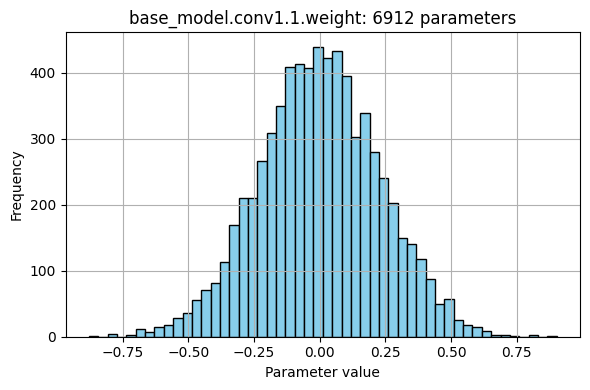

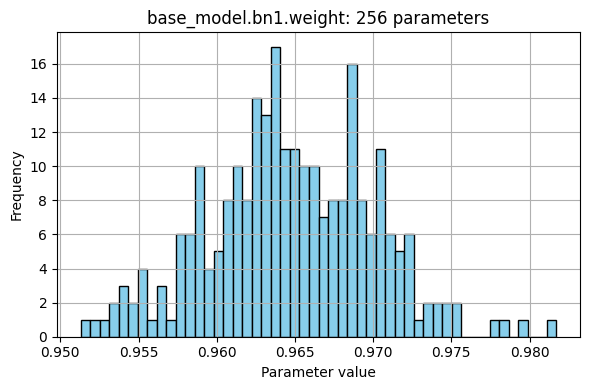

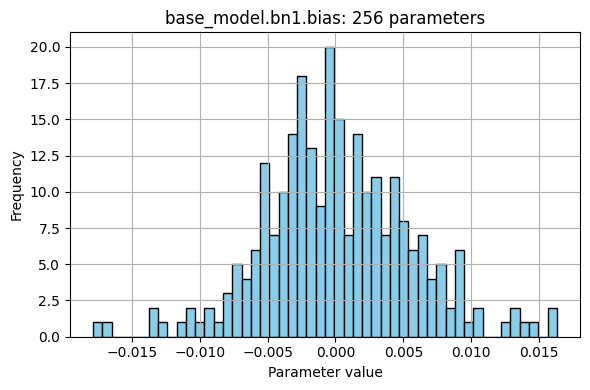

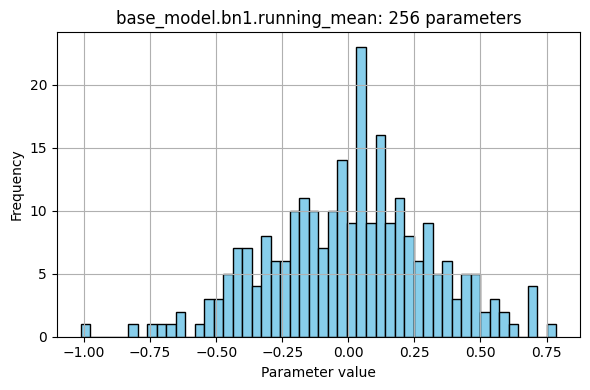

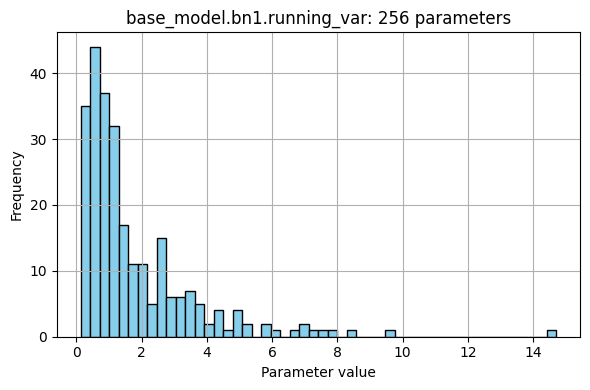

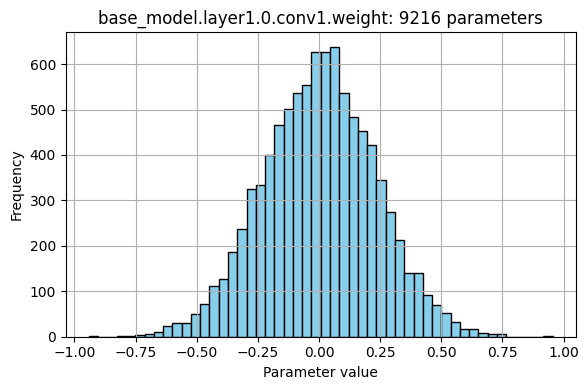

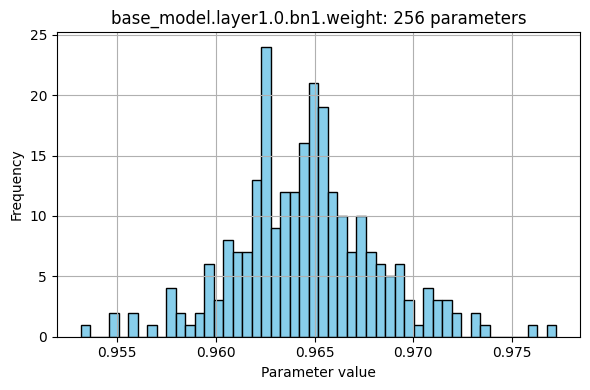

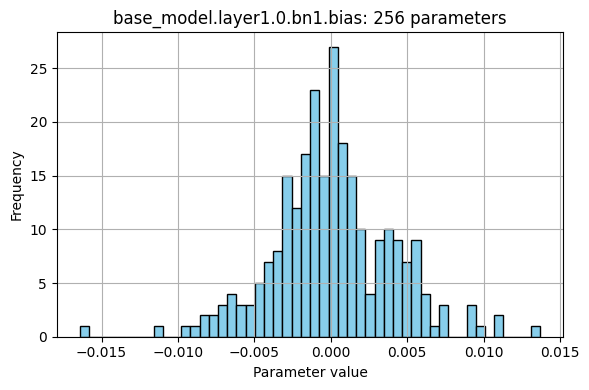

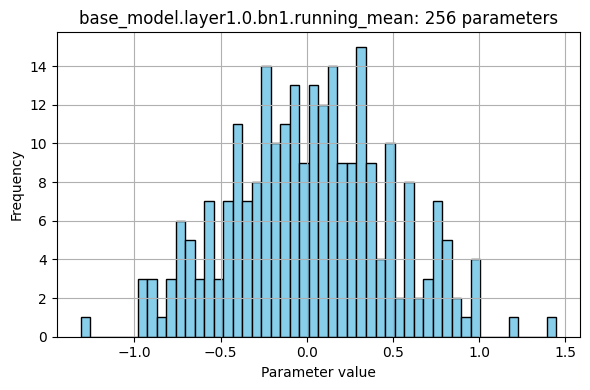

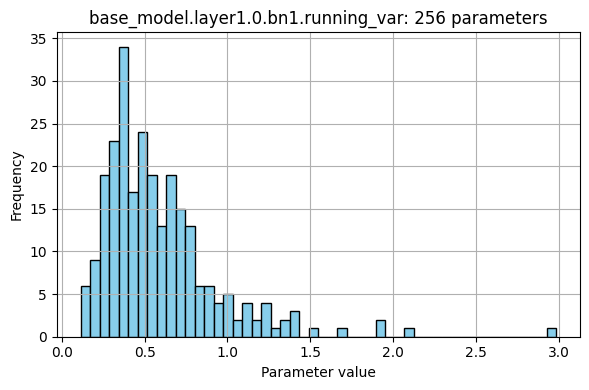

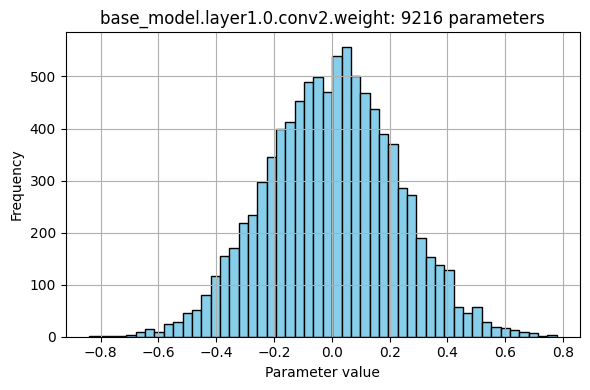

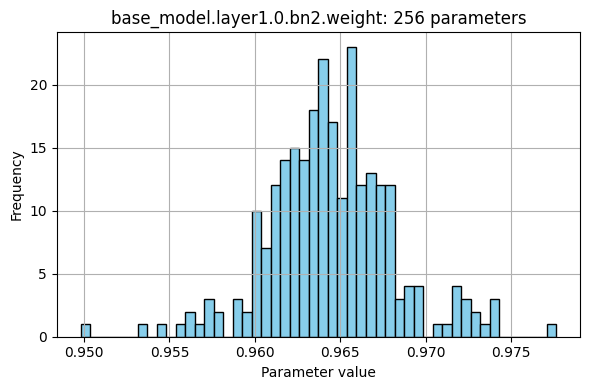

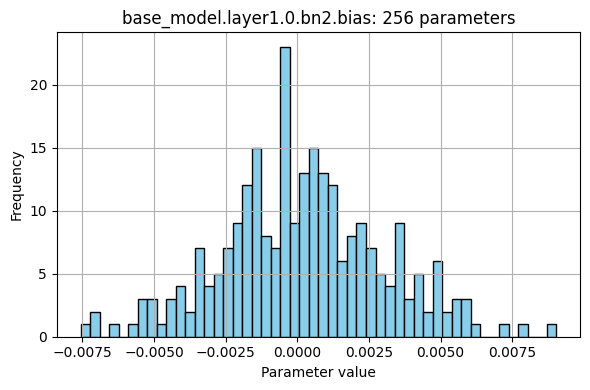

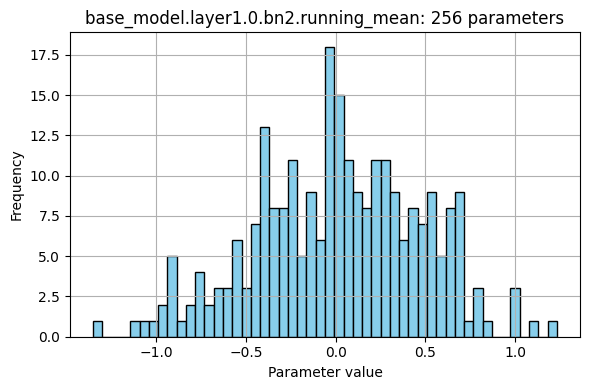

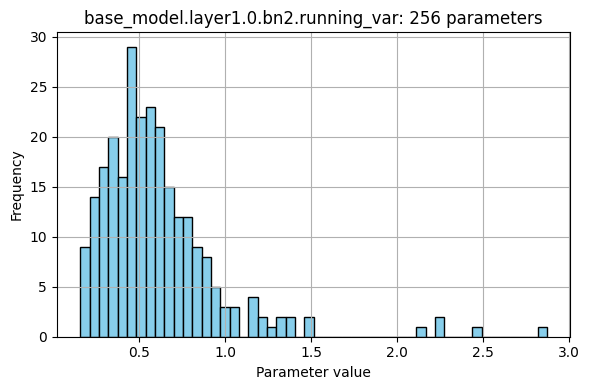

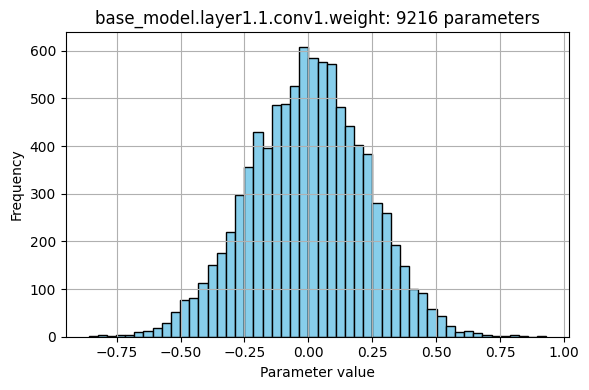

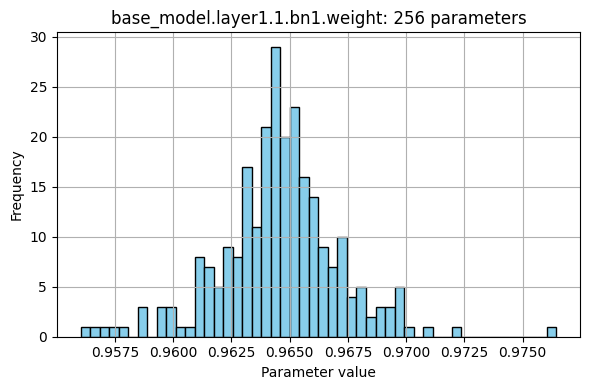

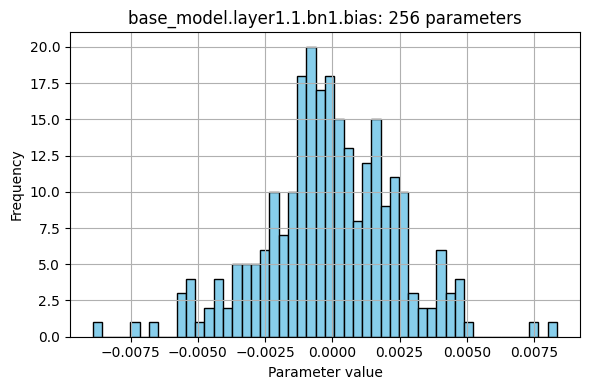

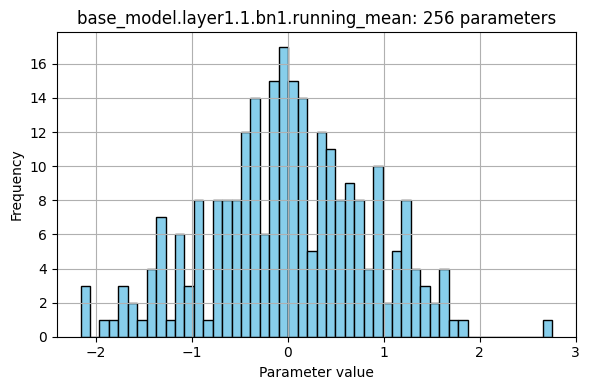

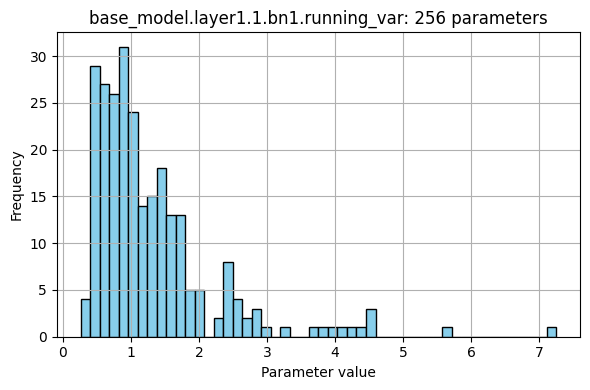

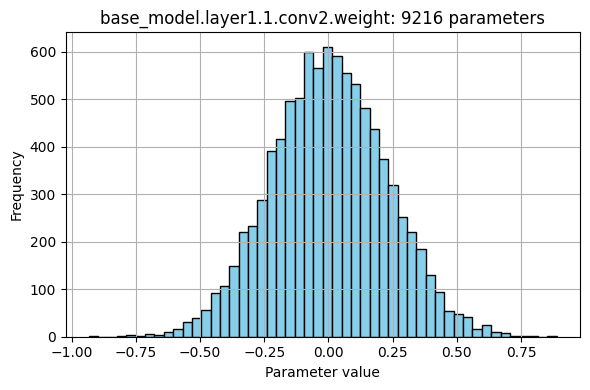

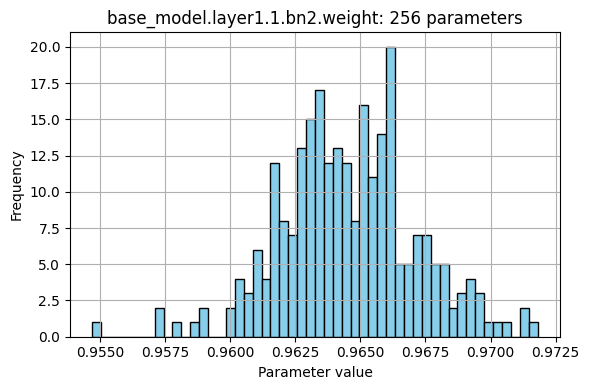

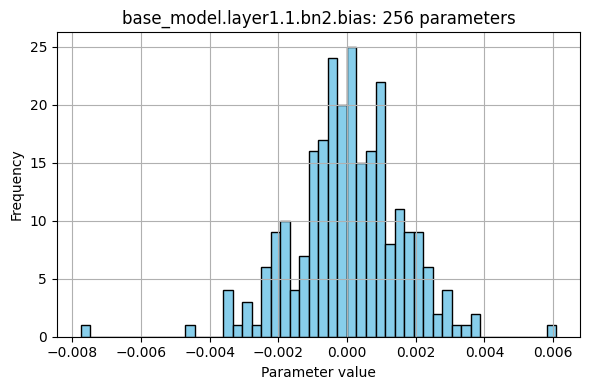

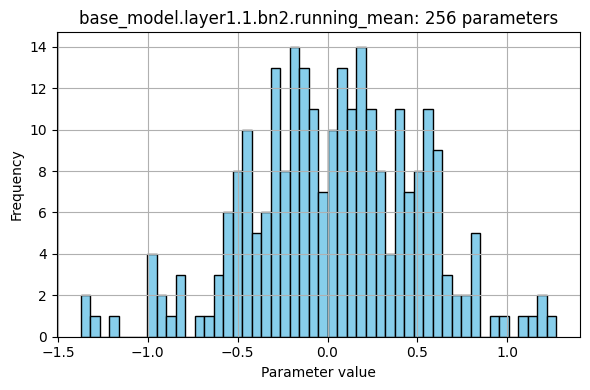

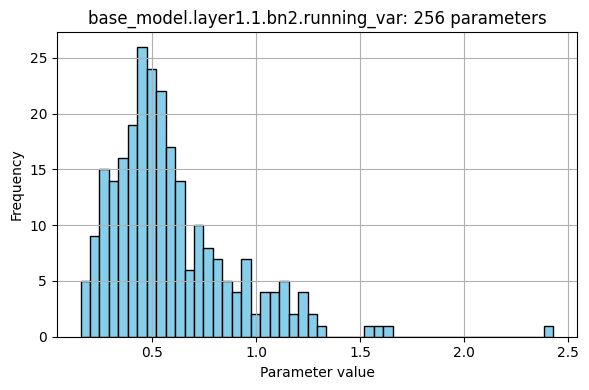

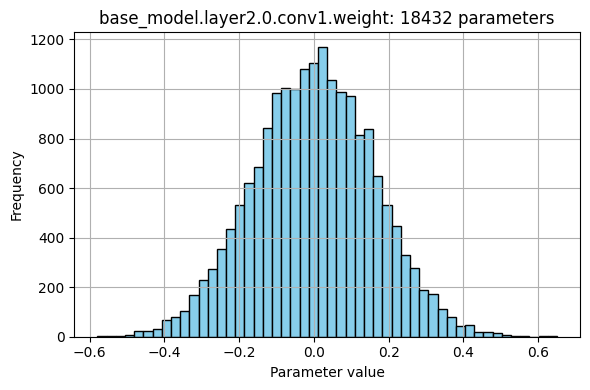

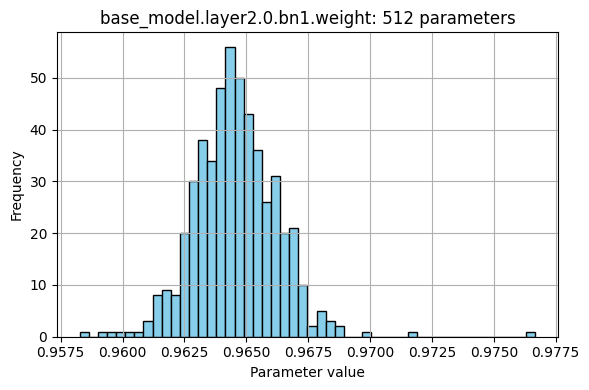

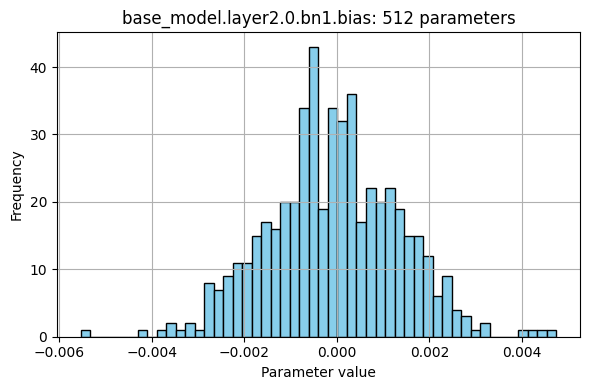

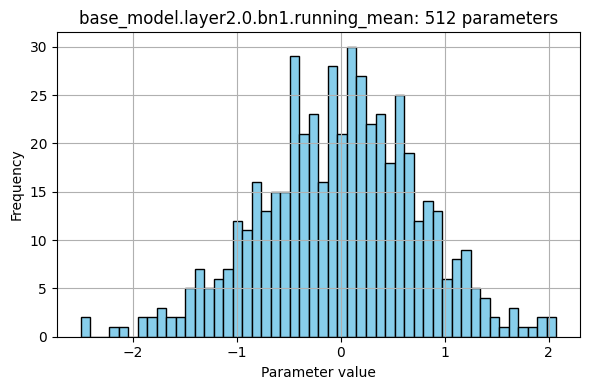

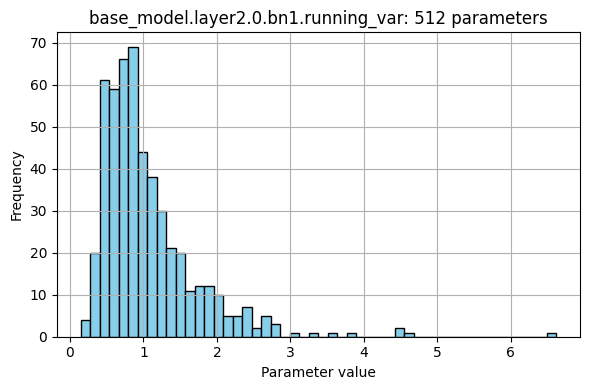

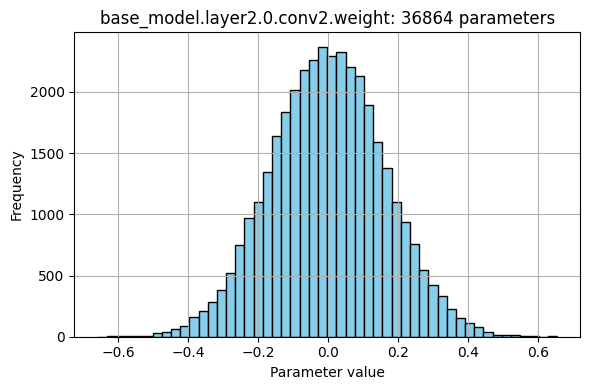

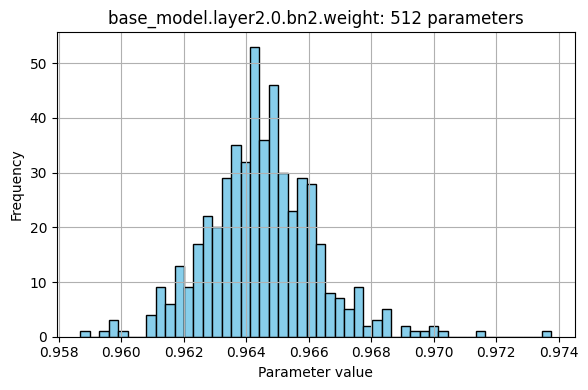

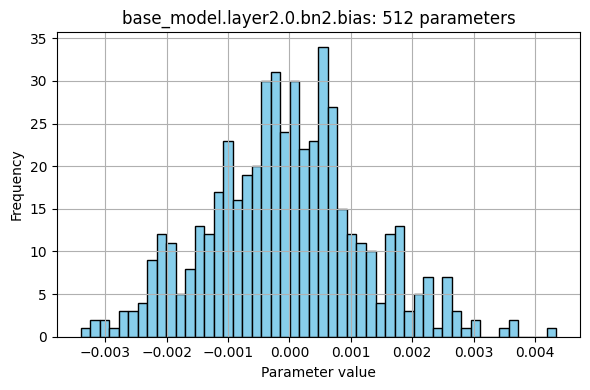

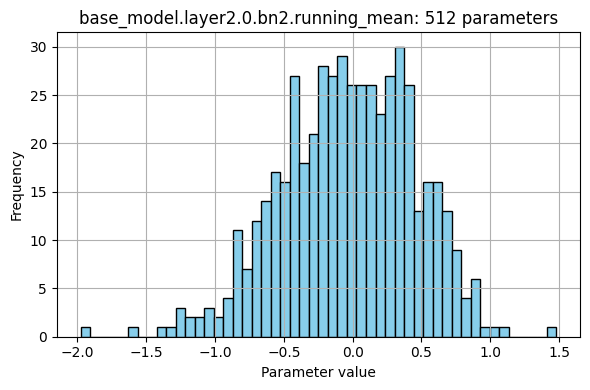

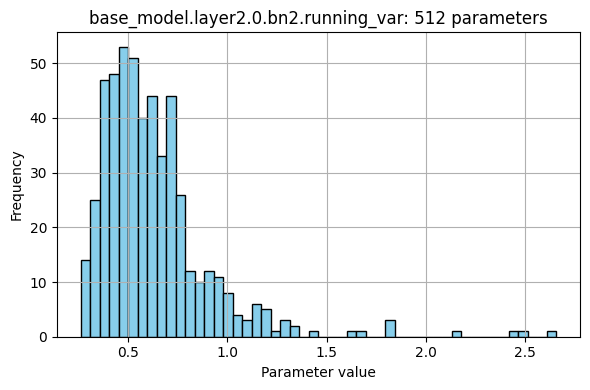

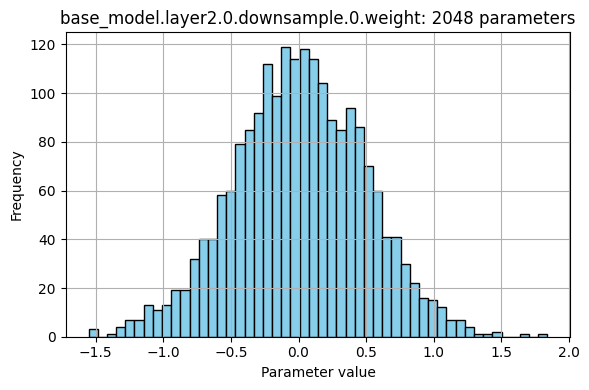

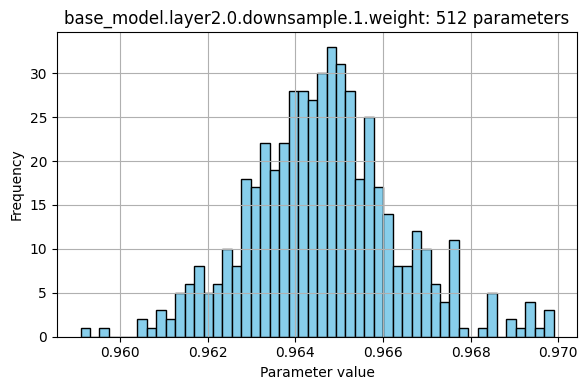

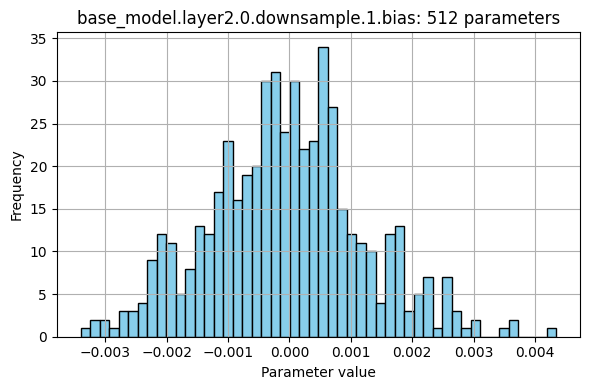

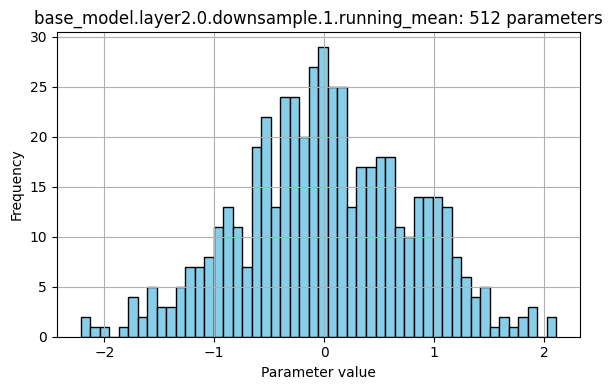

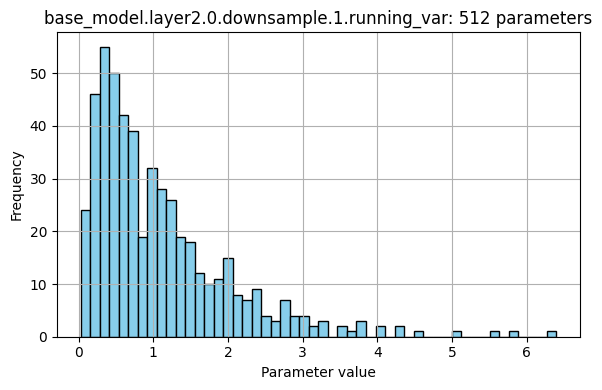

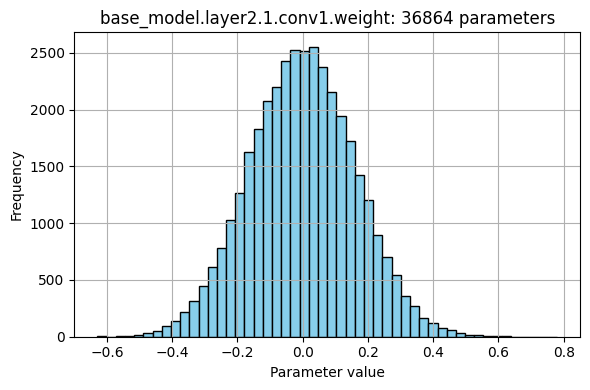

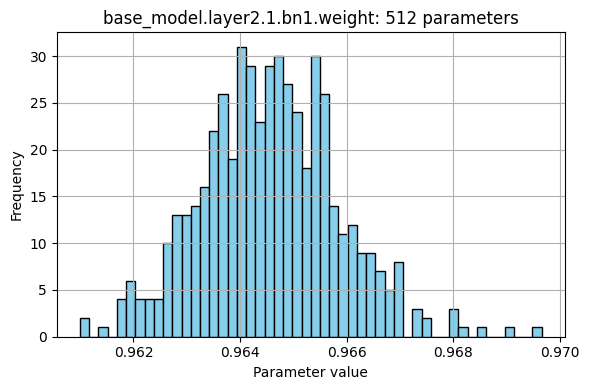

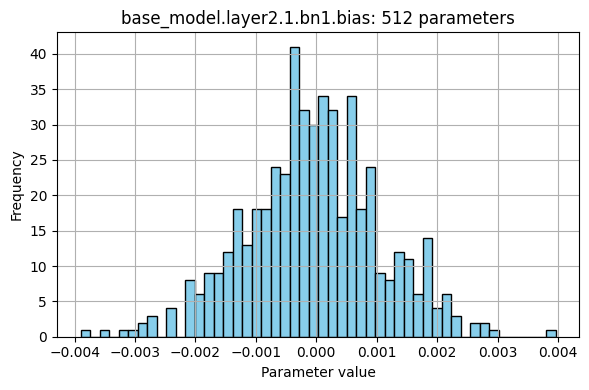

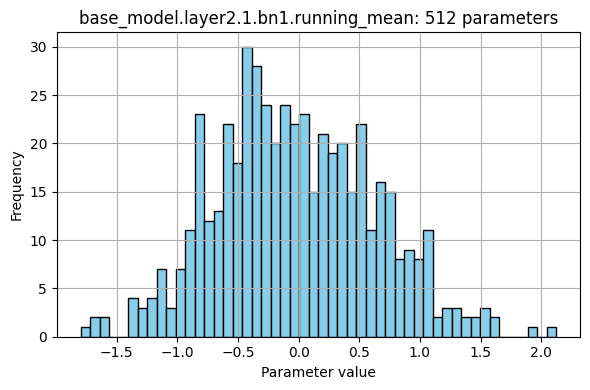

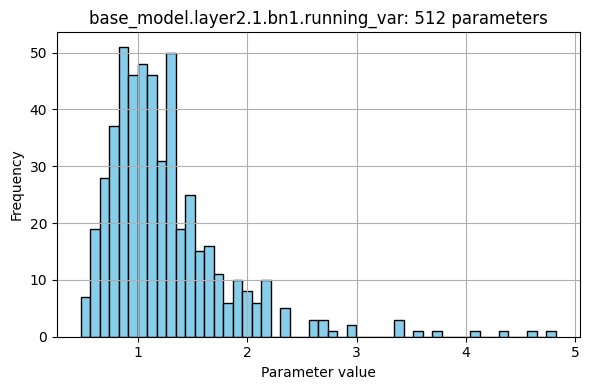

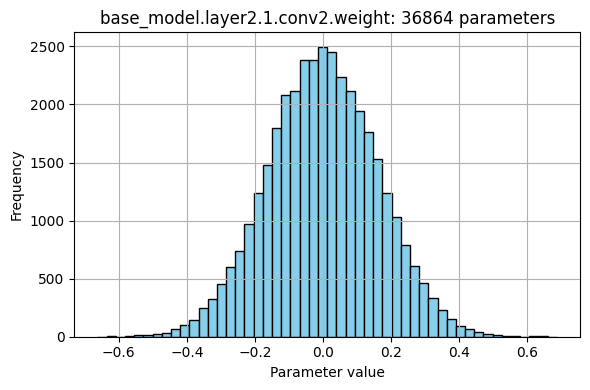

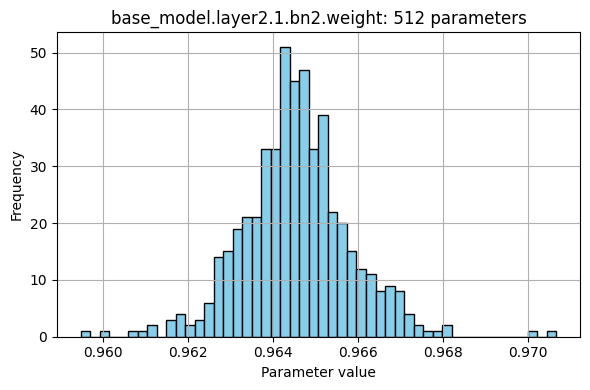

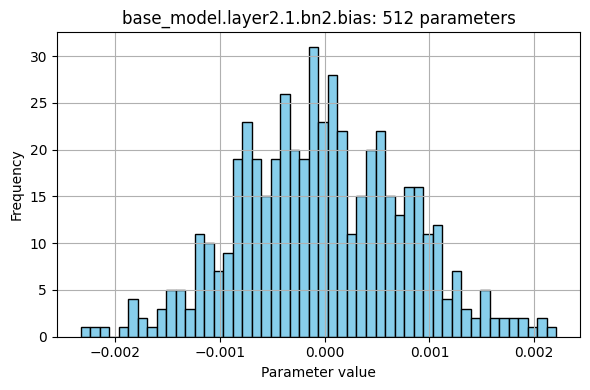

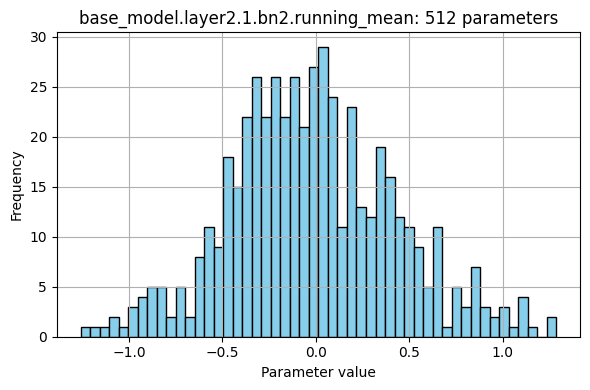

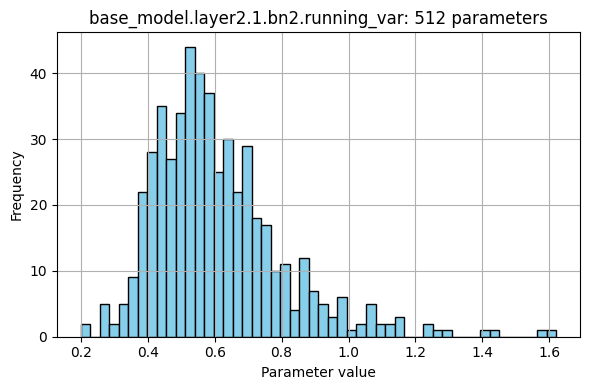

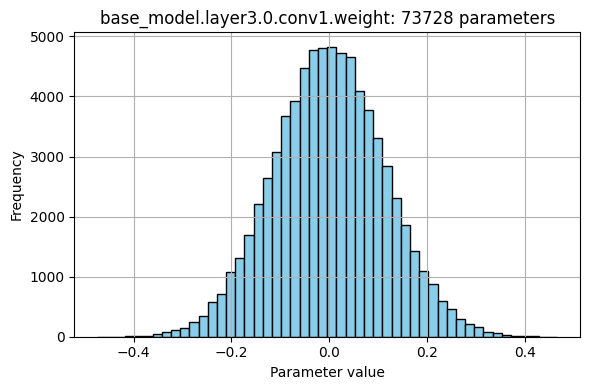

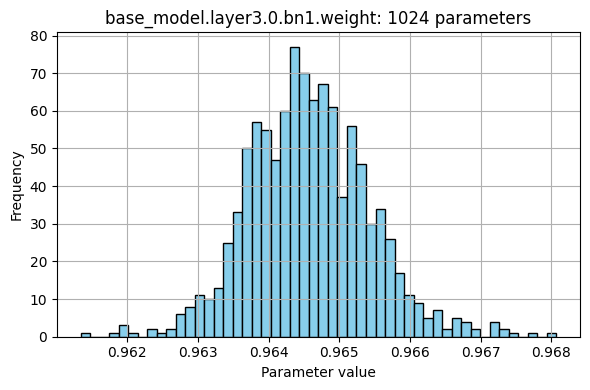

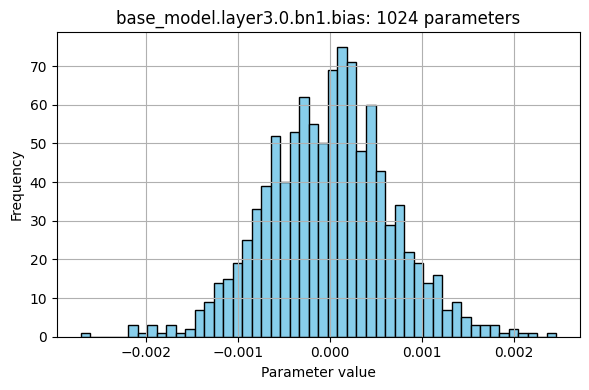

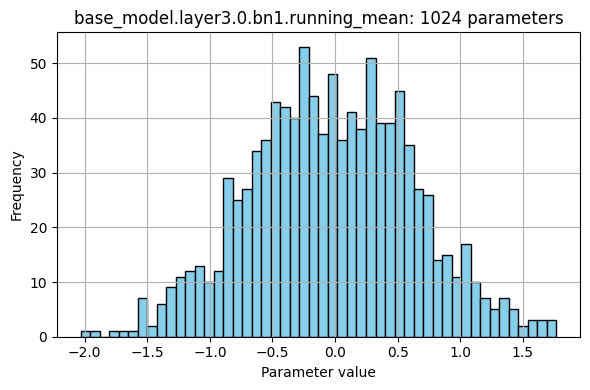

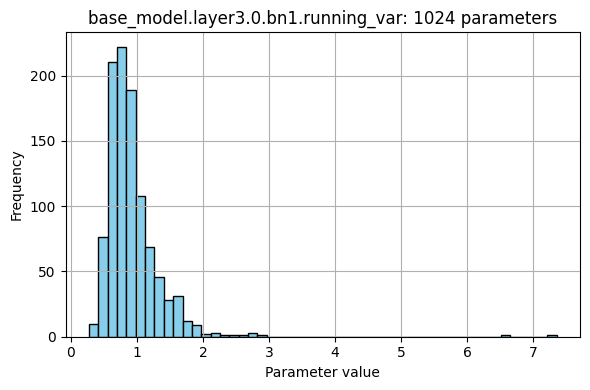

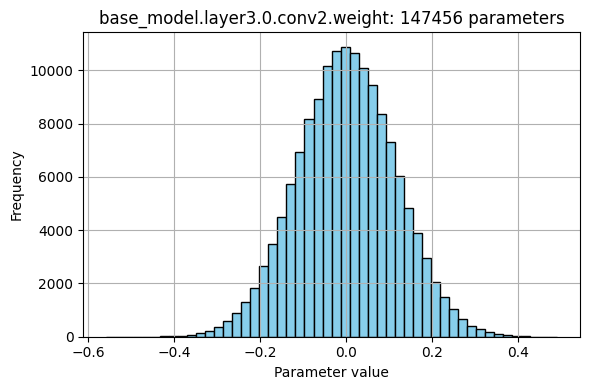

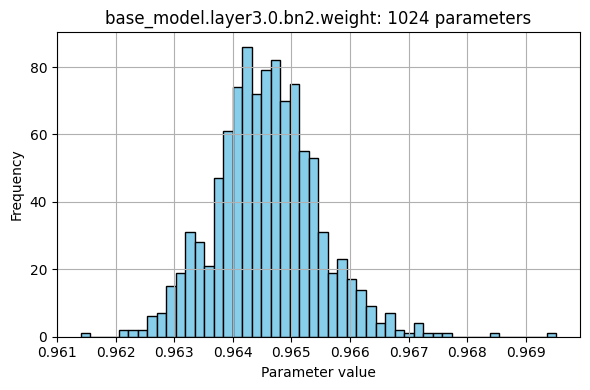

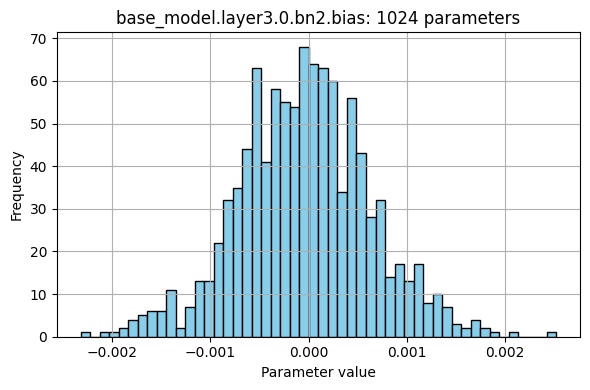

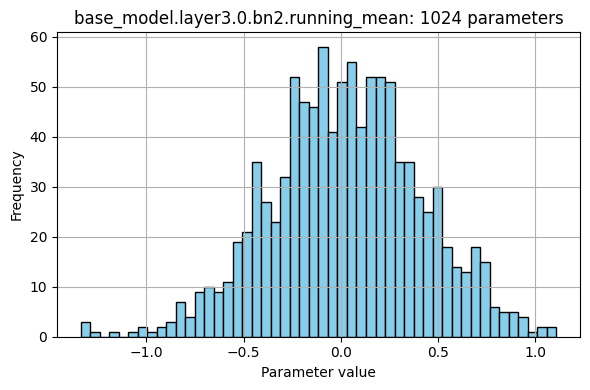

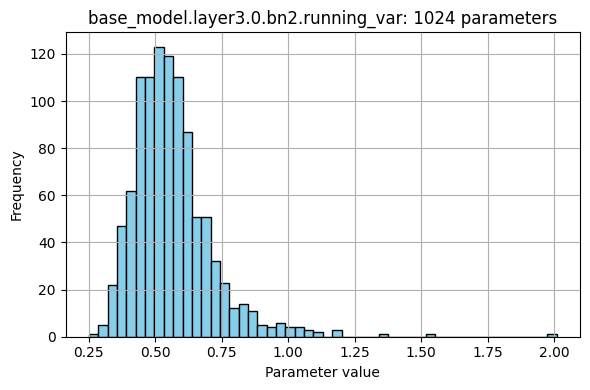

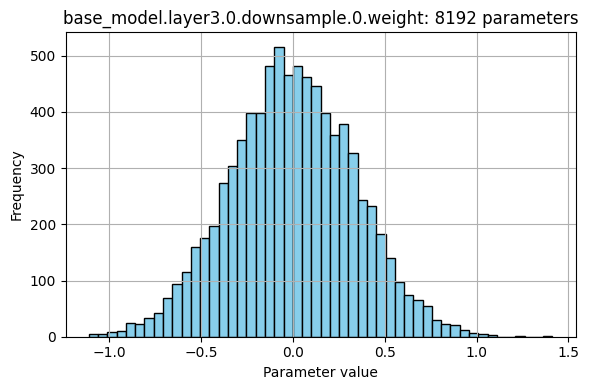

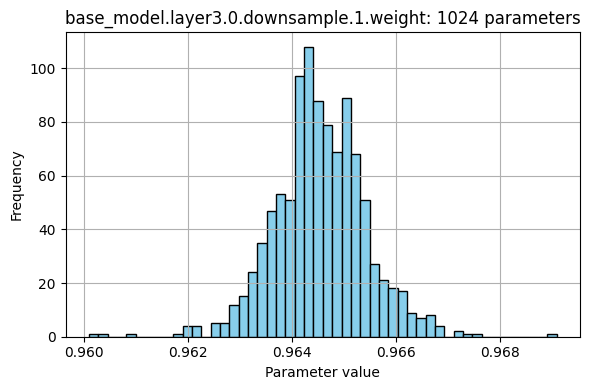

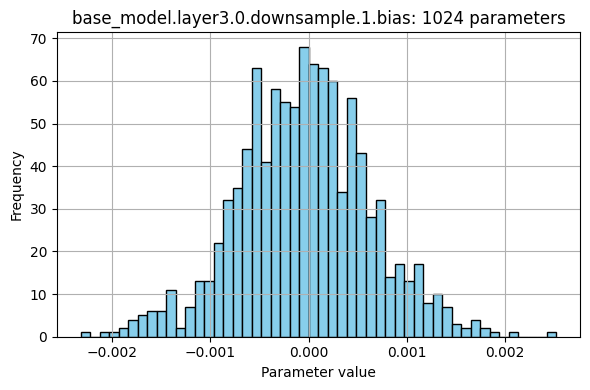

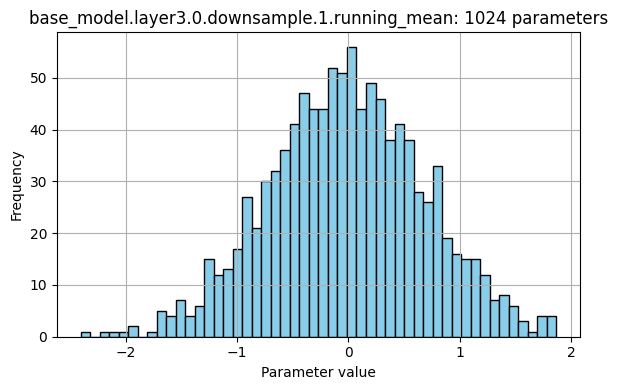

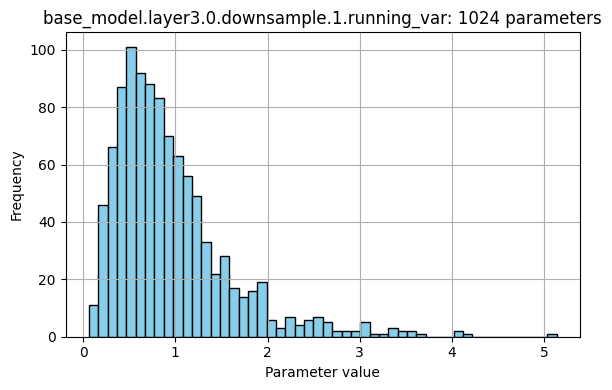

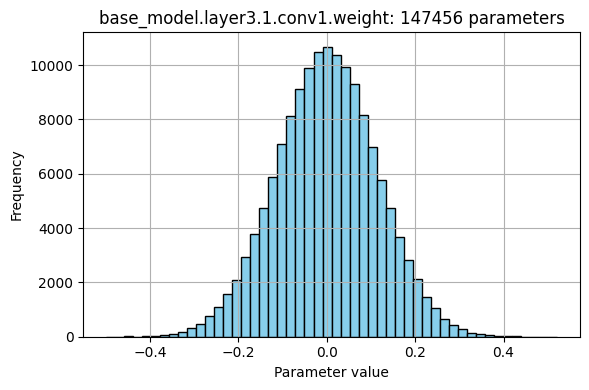

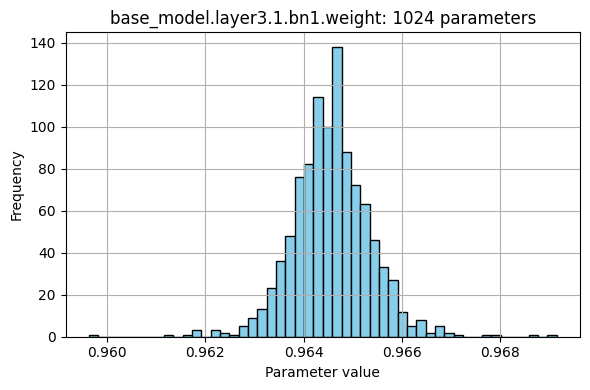

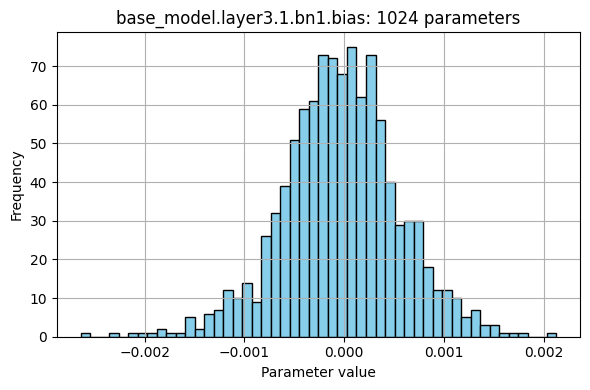

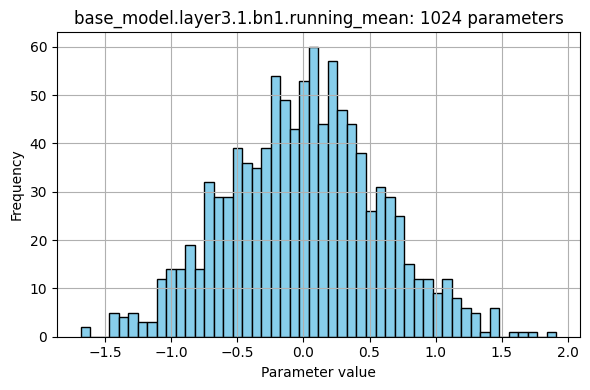

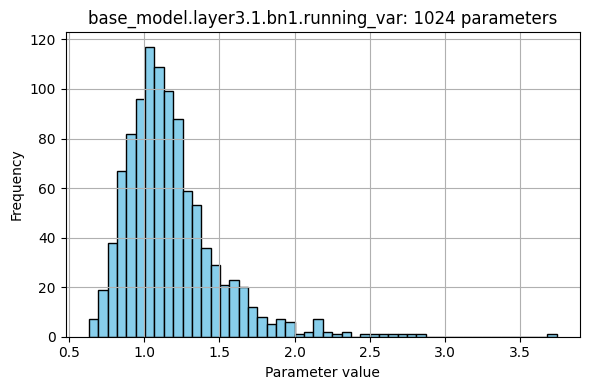

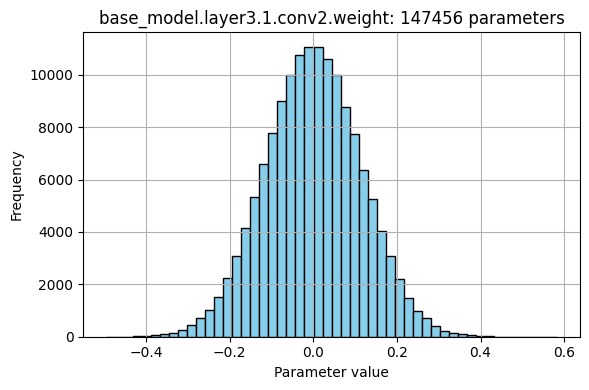

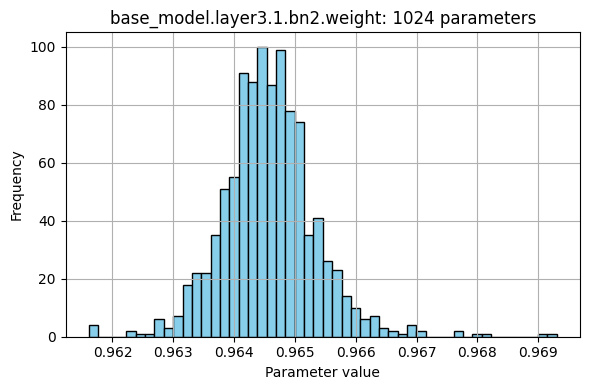

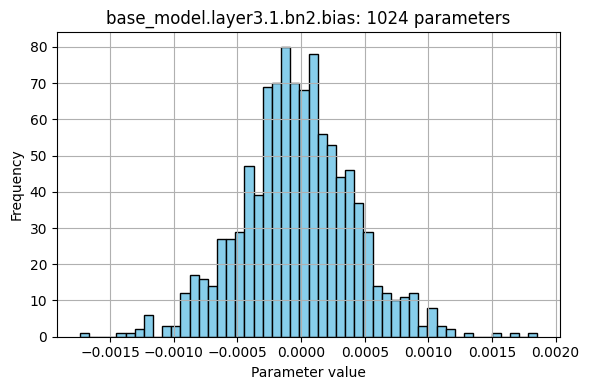

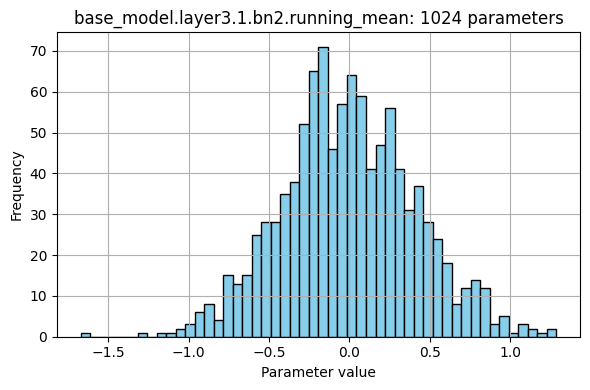

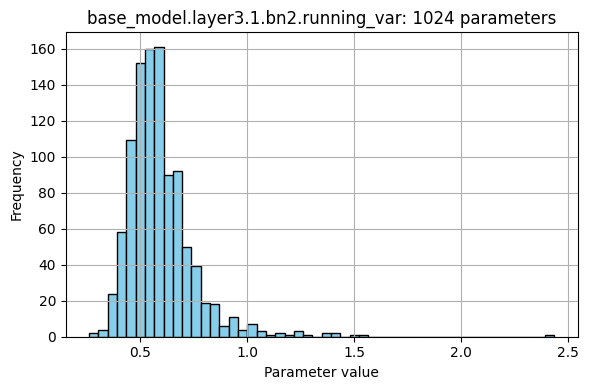

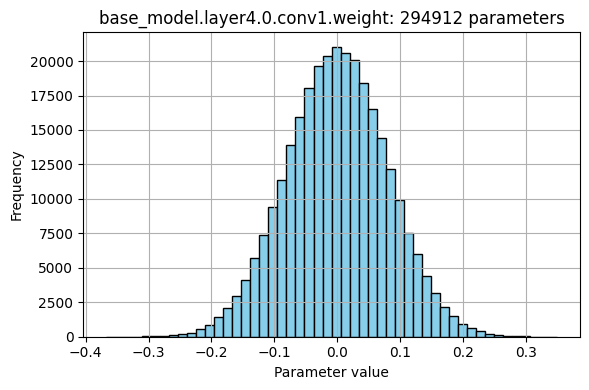

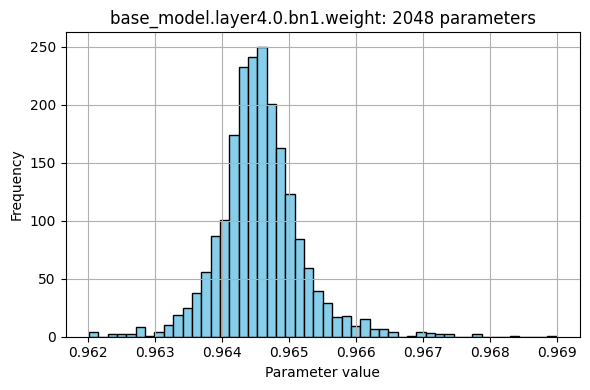

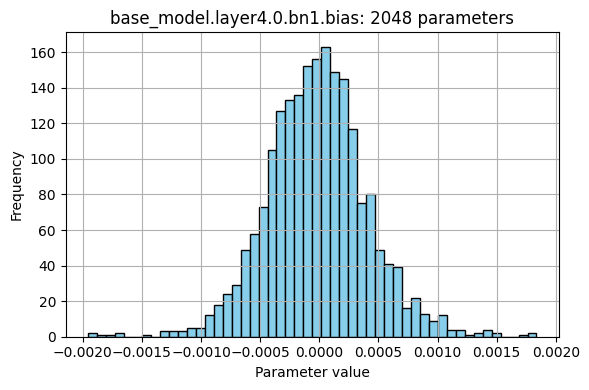

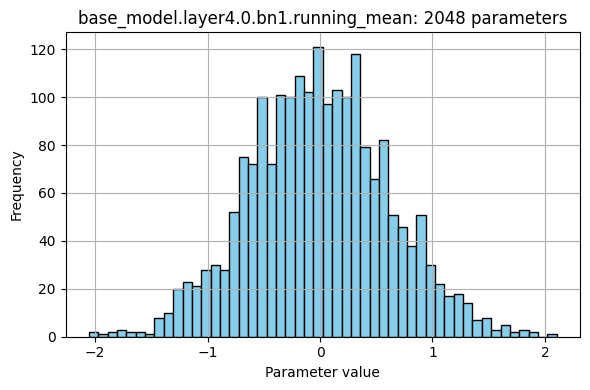

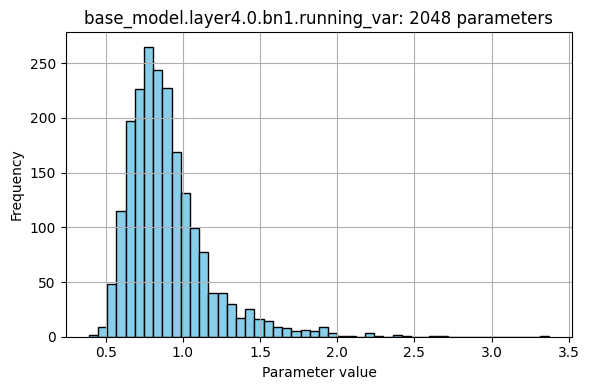

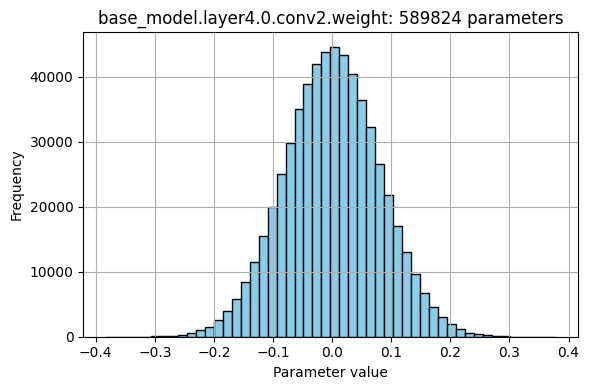

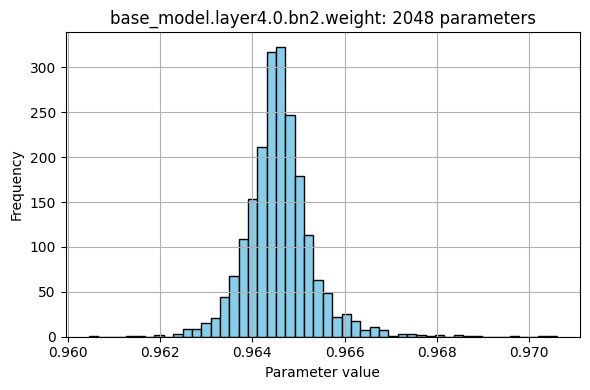

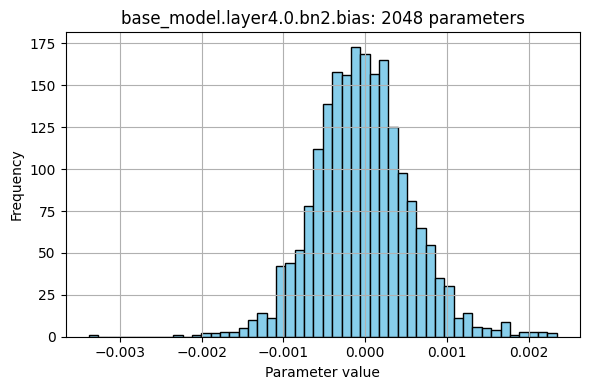

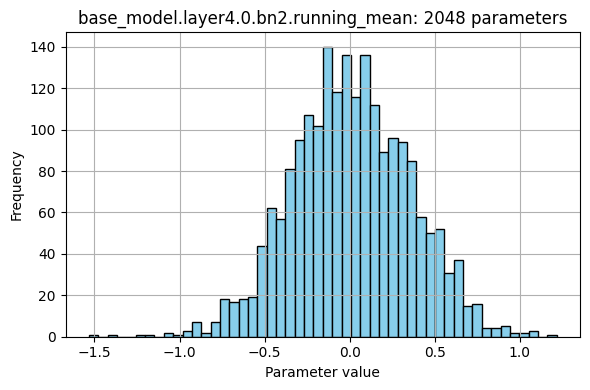

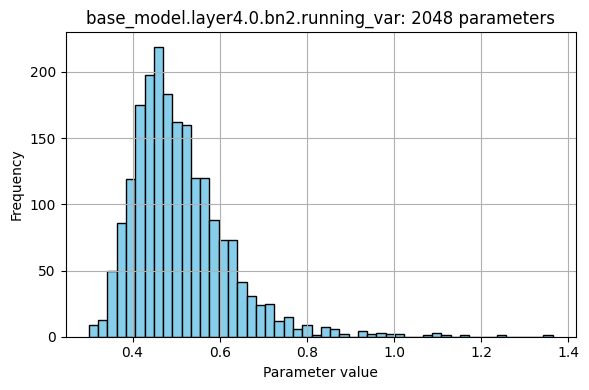

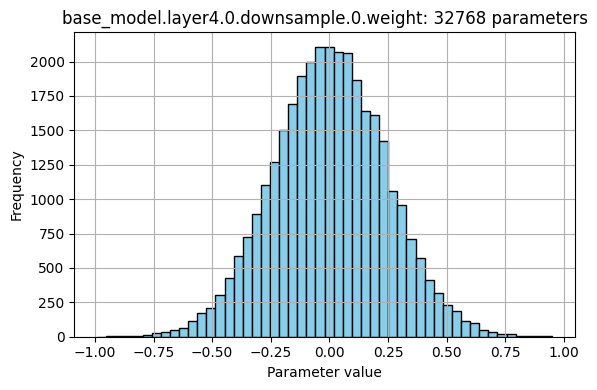

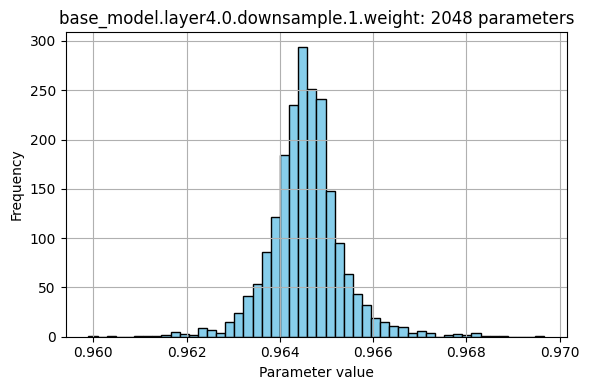

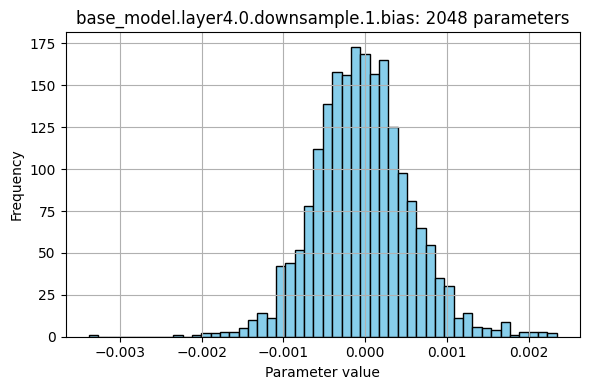

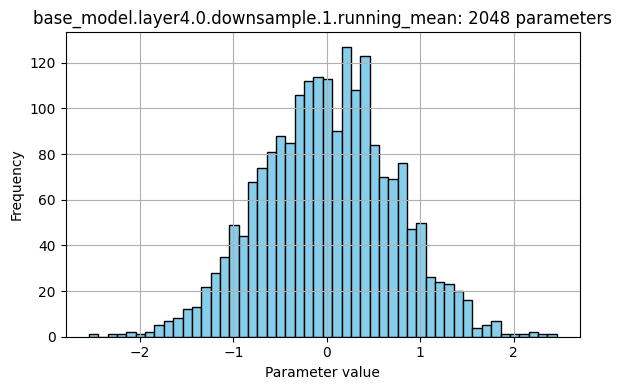

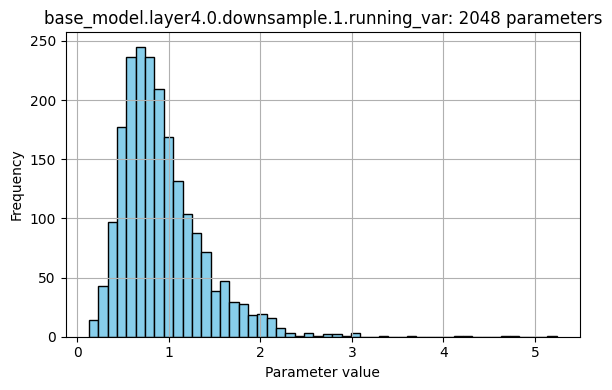

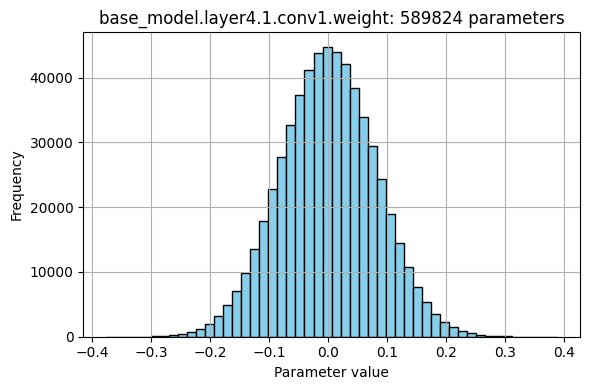

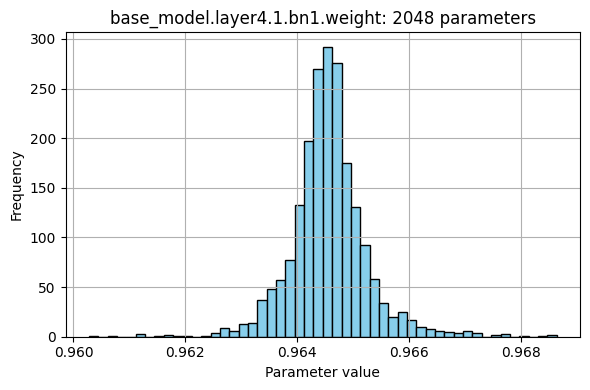

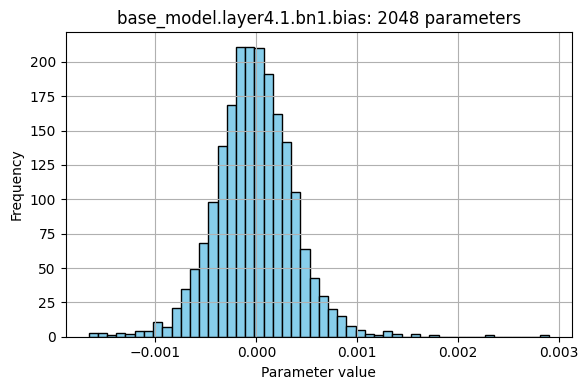

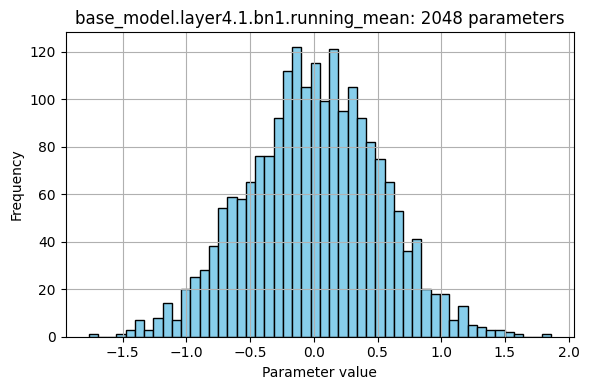

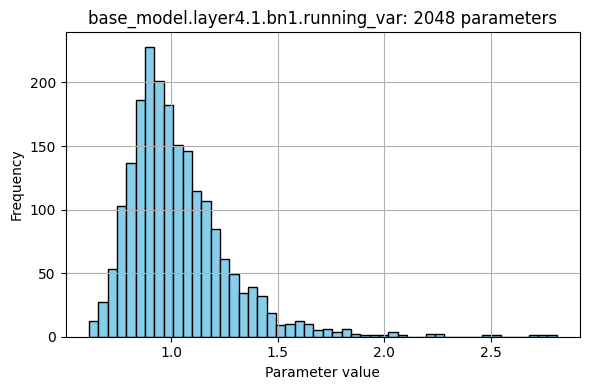

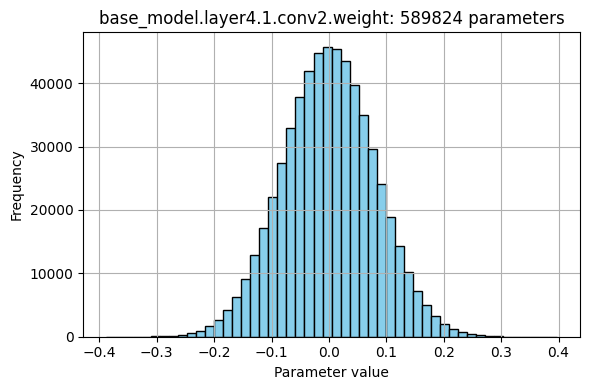

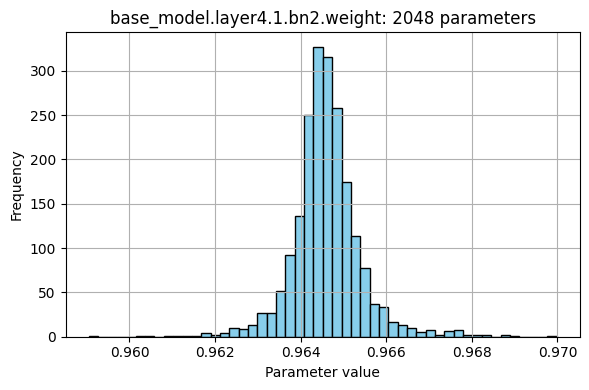

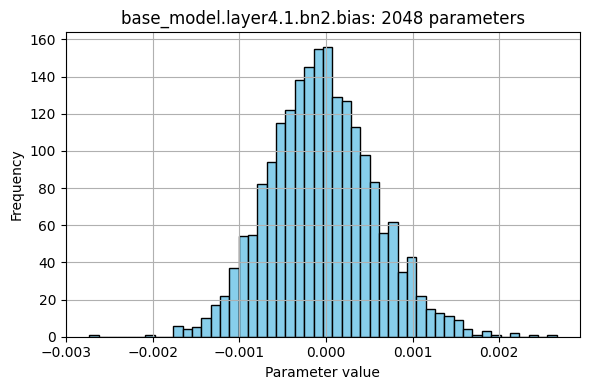

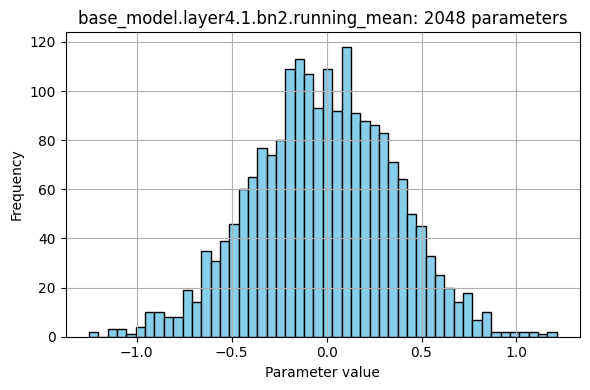

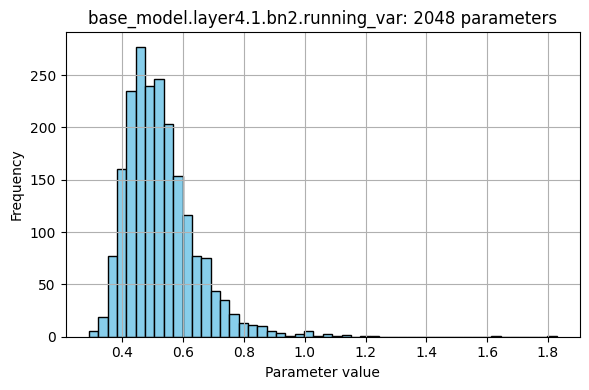

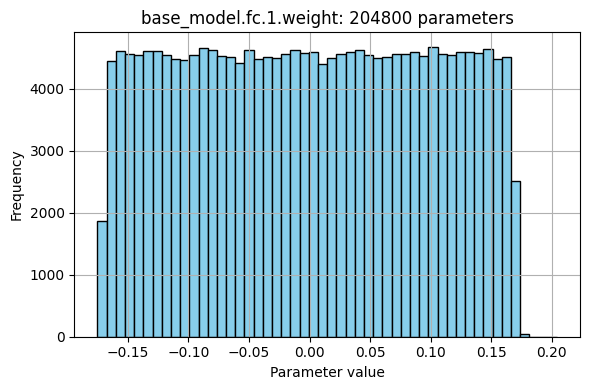

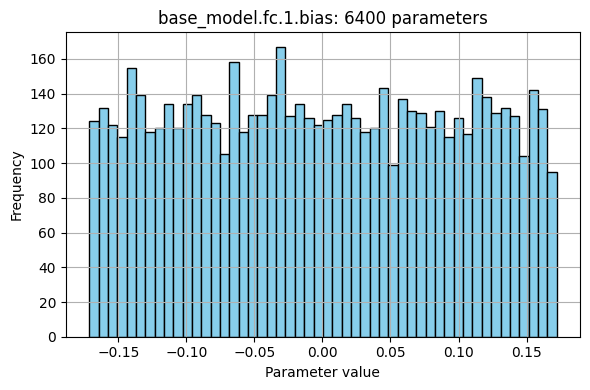

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

for name, param in sd.items():
    if param.dtype not in (torch.float32, torch.float64, torch.float16):
        continue  # 数値でない（int型など）の場合はスキップ

    data = param.cpu().numpy().flatten()  # NumPy配列に変換
    num_params = data.size

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=50, color='skyblue', edgecolor='black')
    plt.title(f"{name}: {num_params} parameters")
    plt.xlabel("Parameter value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
